### 安裝測試相關套件

In [1]:
import pystac_client
import planetary_computer
import stackstac
import rioxarray
import xarray as xr
print(f"pystac-client: {pystac_client.__version__}")
print(f"stackstac:      {stackstac.__version__}")
print(f"rioxarray:      {rioxarray.__version__}")
print("✅ 第 8 週套件已全部就緒！")

pystac-client: 0.9.0
stackstac:      0.5.1
rioxarray:      0.19.0
✅ 第 8 週套件已全部就緒！


In [2]:
import pystac_client
import planetary_computer as pc

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=pc.sign_inplace,
)

mataian_bbox = [121.28, 23.56, 121.52, 23.76]

search_pre = catalog.search(
    collections=["sentinel-2-l2a"],
    bbox=mataian_bbox,
    datetime="2025-06-01/2025-07-15",
    query={"eo:cloud_cover": {"lt": 20}},
)

items_pre = search_pre.item_collection()
print(f"事件前（6 月–7 月上旬）：{len(items_pre)} 張乾淨影像")

事件前（6 月–7 月上旬）：1 張乾淨影像


c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35261 (\N{CJK UNIFIED IDEOGRAPH-89BD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\vicky\anaconda3\envs\gis\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20107 (\N{CJK UNIFIED IDE

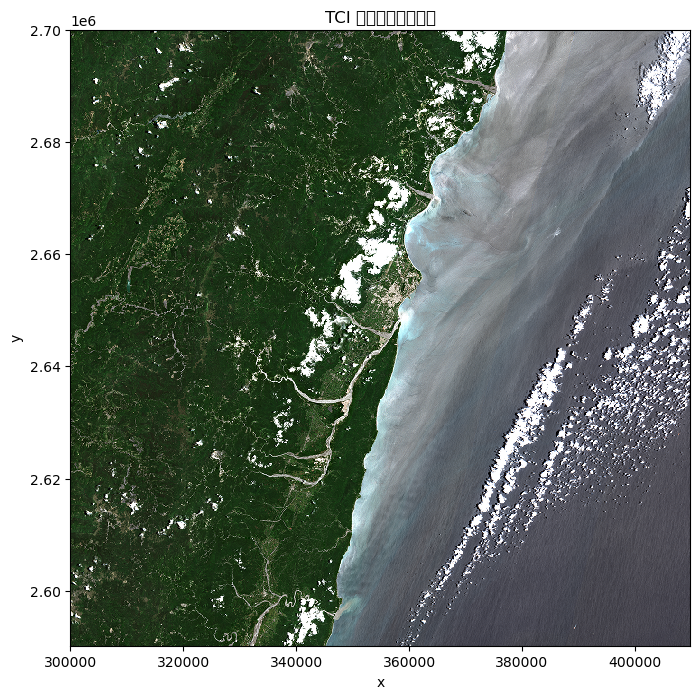

In [3]:
import rioxarray as rxr
import matplotlib.pyplot as plt

best_pre = min(items_pre, key=lambda i: i.properties["eo:cloud_cover"])

tci_href = best_pre.assets["visual"].href
tci = rxr.open_rasterio(tci_href, overview_level=3)

fig, ax = plt.subplots(figsize=(8, 8))
tci.plot.imshow(ax=ax)
ax.set_title("TCI 預覽圖（事件前）")
plt.show()

In [4]:
import stackstac

wanted_bands = ["B02", "B03", "B04", "B08", "B11", "B12"]

cube = stackstac.stack(
    [best_pre],
    assets=wanted_bands,
    epsg=32651,
    resolution=10,
    bounds_latlon=mataian_bbox,
    chunksize=2048,
)

print(f"Cube dims: {dict(cube.sizes)}")
print("✅ STAC 串流正常")

Cube dims: {'time': 1, 'band': 6, 'y': 2243, 'x': 2474}
✅ STAC 串流正常


### 自行建立 guangfu_overlay.gpkg

In [5]:
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path

# --- 1. Build the in-memory GeoDataFrame ---
rows = [
    {"name": "Guangfu_Station",        "cn_name": "光復火車站",        "node_type": "critical_infra", "priority": 2, "lon": 121.4235, "lat": 23.6719},
    {"name": "Guangfu_Elementary",     "cn_name": "光復國小",          "node_type": "shelter",        "priority": 1, "lon": 121.4240, "lat": 23.6688},
    {"name": "Guangfu_Township_Office","cn_name": "光復鄉公所",        "node_type": "shelter",        "priority": 1, "lon": 121.4210, "lat": 23.6684},
    {"name": "Mataian_Hwy9_Bridge",    "cn_name": "台9線馬太鞍溪橋",   "node_type": "bridge",         "priority": 1, "lon": 121.4100, "lat": 23.6380},
    {"name": "Foxu_Debris_Zone",       "cn_name": "佛祖街沉積區中心",  "node_type": "critical_infra", "priority": 3, "lon": 121.4260, "lat": 23.6640},
]

# TODO 1: Convert `rows` into a GeoDataFrame.
#   - geometry column should be built with Point(lon, lat)
#   - initial CRS is EPSG:4326 (WGS84 lon/lat)

gdf = gpd.GeoDataFrame(
    rows,
    geometry=[Point(r["lon"], r["lat"]) for r in rows],
    crs="EPSG:4326",
).drop(columns=["lon", "lat"])

# TODO 2: Reproject to EPSG:3826 (TWD97 / TM2 — Taiwan official)
gdf_3826 = gdf.to_crs("EPSG:3826")

# TODO 3: Ensure the output folder exists
out_path = Path("data/guangfu_overlay.gpkg")
out_path.parent.mkdir(parents=True, exist_ok=True)

# TODO 4: Save as GeoPackage, driver="GPKG", layer="guangfu"
gdf_3826.to_file(out_path, driver="GPKG", layer="guangfu")

print(f"✅ Saved {len(gdf_3826)} nodes → {out_path}")
print(gdf_3826[["name", "cn_name", "node_type", "priority"]])

✅ Saved 5 nodes → data\guangfu_overlay.gpkg
                      name   cn_name       node_type  priority
0          Guangfu_Station     光復火車站  critical_infra         2
1       Guangfu_Elementary      光復國小         shelter         1
2  Guangfu_Township_Office     光復鄉公所         shelter         1
3      Mataian_Hwy9_Bridge  台9線馬太鞍溪橋          bridge         1
4         Foxu_Debris_Zone  佛祖街沉積區中心  critical_infra         3


In [6]:
# Verify the file is readable and the schema is correct
check = gpd.read_file("data/guangfu_overlay.gpkg", layer="guangfu")
assert len(check) == 5,               f"Expected 5 rows, got {len(check)}"
assert check.crs.to_epsg() == 3826,   f"Expected EPSG:3826, got {check.crs}"
assert set(check["node_type"]) == {"shelter", "critical_infra", "bridge"}, \
       "node_type must include all three categories"
print("✅ guangfu_overlay.gpkg passes all schema checks")

✅ guangfu_overlay.gpkg passes all schema checks
